# MLIP–DFT Benchmark Workflow

This notebook provides a reusable workflow for comparing DFT reference calculations with MLIP predictions.

The main goals are:

- avoid hardcoded paths;
- make the workflow easy to modify for new datasets;
- support restarted VASP calculations such as `vasprun.xml-1`, `vasprun.xml-2`, etc.;
- keep the fixed-DFT-geometry comparison as the default benchmark;
- leave room for future extensions such as adsorption energies and MLIP-driven relaxations.


## 1. Imports and basic setup

This section loads the Python packages used throughout the notebook.

If a package is missing, install it inside the same conda environment used to run the notebook.


In [6]:
from pathlib import Path
import re
import json
import subprocess
import sys

import numpy as np
import pandas as pd

try:
    from ase.io import read, write
except ImportError as exc:
    raise ImportError(
        "ASE is required for this workflow. Install it with: conda install -c conda-forge ase"
    ) from exc

print("MLIP–DFT Benchmark Workflow")
print("-" * 28)
print("This notebook will:")
print("  1. Locate VASP reference files")
print("  2. Convert DFT structures into ASE-readable files")
print("  3. Run selected MLIP model scripts")
print("  4. Collect results into a summary table")

MLIP–DFT Benchmark Workflow
----------------------------
This notebook will:
  1. Locate VASP reference files
  2. Convert DFT structures into ASE-readable files
  3. Run selected MLIP model scripts
  4. Collect results into a summary table


## 2. User settings

We need to edit this section for each new dataset.

The goal is to keep all user-specific choices here instead of hiding them throughout the notebook.


In [7]:
# User-editable configuration

CONFIG = {
    # Folder containing the VASP outputs for the benchmark case.
    # Example:
    # "dataset_folder": "/Users/elianorengel/Desktop/CO3_Rec_Ag111_2x2"
    "dataset_folder": "./CO3_Rec_Ag111_2x2",

    # Name used in output files.
    "run_label": "CO3_Rec_Ag111_2x2",

    # If True, the code will use vasprun.xml if present.
    # Otherwise, it will choose the highest-numbered file, such as vasprun.xml-2.
    "prefer_plain_vasprun": True,

    # Whether to read only the final structure or all ionic steps from vasprun.xml.
    # Use ":" for all frames, "-1" for only the final frame.
    "frame_selection": ":",

    # Output folder for xyz, npz, csv, and logs.
    "output_folder": "./benchmark_outputs",

    # MLIP model scripts.
    # Set enabled to False for models you do not want to run.
    "models": {
        "mace": {
            "enabled": True,
            "python": sys.executable,
            "script": "./model_runners/run_mace.py",
            "extra_args": []
        },
        "mattersim": {
            "enabled": True,
            "python": "/opt/miniconda3/envs/mattersim/bin/python",
            "script": "model_runners/run_mattersim.py",
            "extra_args": []
        },
        "uma": {
            "enabled": True,
            "python": "/opt/miniconda3/envs/uma/bin/python",
            "script": "./model_runners/run_uma.py",
            "extra_args": ["--task", "oc20", "--device", "cpu"]
        }
    }
}

DATASET_FOLDER = Path(CONFIG["dataset_folder"]).expanduser().resolve()
OUTPUT_FOLDER = Path(CONFIG["output_folder"]).expanduser().resolve()
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

print("Configuration loaded")
print(f"Dataset folder: {DATASET_FOLDER}")
print(f"Output folder:  {OUTPUT_FOLDER}")
print(f"Run label:      {CONFIG['run_label']}")


Configuration loaded
Dataset folder: /Users/elianorengel/Desktop/2026 Summer Research Program/Mlip-dft-comparison-main/CO3_Rec_Ag111_2x2
Output folder:  /Users/elianorengel/Desktop/2026 Summer Research Program/Mlip-dft-comparison-main/benchmark_outputs
Run label:      CO3_Rec_Ag111_2x2


## 3. Locate VASP files

VASP jobs are often restarted several times.  
That can create files such as:

```text
vasprun.xml-1
vasprun.xml-2
vasprun.xml-3
vasprun.xml
```

The helper functions below allow the workflow to use those files without requiring manual renaming.


In [8]:
def numbered_suffix(path: Path, base_name: str):
    """
    Return the numeric suffix of files like 'vasprun.xml-2'.

    Files without a numeric suffix return None.
    """
    pattern = rf"^{re.escape(base_name)}-(\d+)$"
    match = re.match(pattern, path.name)
    if match:
        return int(match.group(1))
    return None


def find_vasp_file(folder, base_name="vasprun.xml", prefer_plain=True):
    """
    Find a VASP file in a folder.

    This function supports both standard names such as 'vasprun.xml'
    and restarted-job names such as 'vasprun.xml-1', 'vasprun.xml-2', etc.

    Parameters
    ----------
    folder:
        Directory containing VASP output files.
    base_name:
        File prefix to search for. Examples: 'vasprun.xml', 'POSCAR', 'CONTCAR'.
    prefer_plain:
        If True and base_name exists, use it first. This is useful because in many
        restarted calculations the unnumbered file is the latest run.

    Returns
    -------
    Path
        Path to the selected file.
    """
    folder = Path(folder)

    plain = folder / base_name
    if prefer_plain and plain.exists():
        return plain

    candidates = []
    if plain.exists():
        candidates.append((0, plain))

    for candidate in folder.glob(f"{base_name}-*"):
        suffix = numbered_suffix(candidate, base_name)
        if suffix is not None:
            candidates.append((suffix, candidate))

    if not candidates:
        raise FileNotFoundError(
            f"Could not find {base_name} or numbered versions like {base_name}-1 in {folder}"
        )

    # Highest suffix is treated as the latest numbered continuation.
    return sorted(candidates, key=lambda item: item[0])[-1][1]


def list_restarted_vasp_files(folder, base_name="vasprun.xml"):
    """
    Return all restarted VASP files in chronological order.

    Example order:
    vasprun.xml-1, vasprun.xml-2, vasprun.xml-3, vasprun.xml
    """
    folder = Path(folder)
    numbered = []

    for candidate in folder.glob(f"{base_name}-*"):
        suffix = numbered_suffix(candidate, base_name)
        if suffix is not None:
            numbered.append((suffix, candidate))

    numbered = [path for _, path in sorted(numbered, key=lambda item: item[0])]

    plain = folder / base_name
    if plain.exists():
        numbered.append(plain)

    return numbered


vasprun_path = find_vasp_file(
    DATASET_FOLDER,
    base_name="vasprun.xml",
    prefer_plain=CONFIG["prefer_plain_vasprun"]
)

all_vaspruns = list_restarted_vasp_files(DATASET_FOLDER, base_name="vasprun.xml")

print("VASP file detection complete")
print(f"Selected vasprun file: {vasprun_path}")
print("Detected VASP run sequence:")
for file in all_vaspruns:
    print(f"  - {file.name}")


VASP file detection complete
Selected vasprun file: /Users/elianorengel/Desktop/2026 Summer Research Program/Mlip-dft-comparison-main/CO3_Rec_Ag111_2x2/vasprun.xml
Detected VASP run sequence:
  - vasprun.xml-1
  - vasprun.xml-2
  - vasprun.xml-3
  - vasprun.xml-4
  - vasprun.xml


## 4. Read DFT reference structures

By default, the notebook evaluates MLIPs on the DFT geometry.

This keeps the comparison controlled: differences in energy and forces come from the potential, not from different relaxed structures.


In [9]:
def read_dft_frames(vasprun_file, frame_selection=":"):
    """
    Read DFT frames from a VASP vasprun.xml file using ASE.

    frame_selection:
    - '-1' reads only the final frame.
    - ':' reads all frames.
    """
    print("\nReading DFT reference structures")
    print(f"Input file: {vasprun_file}")
    print(f"Frame selection: {frame_selection}")

    frames = read(str(vasprun_file), index=frame_selection)

    if not isinstance(frames, list):
        frames = [frames]

    print(f"Number of DFT frames loaded: {len(frames)}")
    return frames


dft_frames = read_dft_frames(vasprun_path, CONFIG["frame_selection"])

ads_xyz = OUTPUT_FOLDER / f"{CONFIG['run_label']}_dft_frames.xyz"

# Extended XYZ preserves useful ASE metadata more reliably than plain XYZ.
write(str(ads_xyz), dft_frames, format="extxyz")

print("\nDFT structures written for MLIP evaluation")
print(f"Output xyz: {ads_xyz}")



Reading DFT reference structures
Input file: /Users/elianorengel/Desktop/2026 Summer Research Program/Mlip-dft-comparison-main/CO3_Rec_Ag111_2x2/vasprun.xml
Frame selection: :
Number of DFT frames loaded: 379

DFT structures written for MLIP evaluation
Output xyz: /Users/elianorengel/Desktop/2026 Summer Research Program/Mlip-dft-comparison-main/benchmark_outputs/CO3_Rec_Ag111_2x2_dft_frames.xyz


## 5. Optional: combine restarted VASP runs

For now, the main benchmark uses the latest selected VASP run.

The function below is included for future work. It can combine all detected `vasprun.xml-*` files into one trajectory.


In [10]:
def combine_vasp_runs(vasprun_files, output_xyz):
    """
    Combine frames from multiple restarted VASP runs into a single trajectory.

    This is useful when a geometry optimization was continued across several jobs.
    Duplicate frames are not removed here; that can be added later if needed.
    """
    combined_frames = []

    print("\nCombining restarted VASP runs")
    for file in vasprun_files:
        print(f"Reading {file.name}")
        frames = read(str(file), index=":", format="vasp-xml")
        if not isinstance(frames, list):
            frames = [frames]
        combined_frames.extend(frames)

    write(str(output_xyz), combined_frames, format="extxyz")

    print(f"Combined frames: {len(combined_frames)}")
    print(f"Combined trajectory written to: {output_xyz}")
    return combined_frames


# Comment this if you do not want to combine all restarted VASP runs:
combined_xyz = OUTPUT_FOLDER / f"{CONFIG['run_label']}_combined_dft_trajectory.xyz"
combined_frames = combine_vasp_runs(all_vaspruns, combined_xyz)



Combining restarted VASP runs
Reading vasprun.xml-1
Reading vasprun.xml-2
Reading vasprun.xml-3
Reading vasprun.xml-4
Reading vasprun.xml
Combined frames: 2226
Combined trajectory written to: /Users/elianorengel/Desktop/2026 Summer Research Program/Mlip-dft-comparison-main/benchmark_outputs/CO3_Rec_Ag111_2x2_combined_dft_trajectory.xyz


## 6. Run MLIP models

Each model is called through its own script.

This keeps the benchmark flexible because different MLIPs may need different conda environments or dependencies.


In [11]:
def run_model(model_name, model_config, input_xyz, output_folder, run_label):
    """
    Run one MLIP model script on the selected DFT structures.

    Expected script interface:
        python run_model.py input.xyz output.npz [extra args]

    The output npz file should contain model predictions such as energies and forces.
    """
    if not model_config.get("enabled", False):
        print(f"[{model_name}] Skipped because enabled=False")
        return None

    python_exe = Path(model_config["python"]).expanduser()
    script = Path(model_config["script"]).expanduser()
    output_npz = output_folder / f"{run_label}_{model_name}.npz"

    command = [
        str(python_exe),
        str(script),
        str(input_xyz),
        str(output_npz),
    ] + list(model_config.get("extra_args", []))

    print("\n" + "-" * 70)
    print(f"[{model_name}] Starting MLIP evaluation")
    print(f"Python executable: {python_exe}")
    print(f"Model script:      {script}")
    print(f"Input xyz:         {input_xyz}")
    print(f"Output npz:        {output_npz}")
    print("-" * 70)

    result = subprocess.run(
        command,
        text=True,
        capture_output=True
    )

    log_file = output_folder / f"{run_label}_{model_name}.log"
    log_file.write_text(
        "COMMAND:\n"
        + " ".join(command)
        + "\n\nSTDOUT:\n"
        + result.stdout
        + "\n\nSTDERR:\n"
        + result.stderr
    )

    if result.returncode != 0:
        print(f"[{model_name}] Failed. See log file: {log_file}")
        print(result.stderr)
        return None

    print(f"[{model_name}] Finished successfully")
    print(f"Log file: {log_file}")
    return output_npz


model_outputs = {}

for model_name, model_config in CONFIG["models"].items():
    output = run_model(
        model_name=model_name,
        model_config=model_config,
        input_xyz=ads_xyz,
        output_folder=OUTPUT_FOLDER,
        run_label=CONFIG["run_label"]
    )
    if output is not None:
        model_outputs[model_name] = output

print("\nModel execution step complete")
print("Available model outputs:")
for name, file in model_outputs.items():
    print(f"  - {name}: {file}")



----------------------------------------------------------------------
[mace] Starting MLIP evaluation
Python executable: /opt/miniconda3/envs/catalysis/bin/python
Model script:      model_runners/run_mace.py
Input xyz:         /Users/elianorengel/Desktop/2026 Summer Research Program/Mlip-dft-comparison-main/benchmark_outputs/CO3_Rec_Ag111_2x2_dft_frames.xyz
Output npz:        /Users/elianorengel/Desktop/2026 Summer Research Program/Mlip-dft-comparison-main/benchmark_outputs/CO3_Rec_Ag111_2x2_mace.npz
----------------------------------------------------------------------
[mace] Finished successfully
Log file: /Users/elianorengel/Desktop/2026 Summer Research Program/Mlip-dft-comparison-main/benchmark_outputs/CO3_Rec_Ag111_2x2_mace.log

----------------------------------------------------------------------
[mattersim] Starting MLIP evaluation
Python executable: /opt/miniconda3/envs/mattersim/bin/python
Model script:      model_runners/run_mattersim.py
Input xyz:         /Users/elianoren

## 7. Extract DFT reference values

This section collects DFT energies and forces directly from the ASE frames.

The exact metadata available depends on what ASE was able to read from `vasprun.xml`.


In [12]:
def extract_dft_reference(frames):
    """
    Extract DFT energies and maximum force magnitudes from ASE Atoms objects.
    """
    rows = []

    for i, atoms in enumerate(frames):
        try:
            energy = atoms.get_potential_energy()
        except Exception:
            energy = np.nan

        try:
            forces = atoms.get_forces()
            max_force = float(np.max(np.linalg.norm(forces, axis=1)))
        except Exception:
            max_force = np.nan

        rows.append({
            "frame": i,
            "dft_energy_eV": energy,
            "dft_max_force_eV_per_A": max_force,
            "natoms": len(atoms)
        })

    return pd.DataFrame(rows)


dft_summary = extract_dft_reference(dft_frames)
dft_summary_path = OUTPUT_FOLDER / f"{CONFIG['run_label']}_dft_summary.csv"
dft_summary.to_csv(dft_summary_path, index=False)

print("DFT reference summary")
display(dft_summary)
print(f"Saved to: {dft_summary_path}")


DFT reference summary


,frame,dft_energy_eV,dft_max_force_eV_per_A,natoms
0,0,-74.437792,0.100255,20
1,1,-74.438300,0.103188,20
2,2,-74.438695,0.152458,20
3,3,-74.438898,0.183256,20
4,4,-74.439207,0.117351,20
...,...,...,...,...
374,374,-74.674421,0.038144,20
375,375,-74.674530,0.054856,20
376,376,-74.674627,0.081411,20
377,377,-74.674749,0.109172,20


Saved to: /Users/elianorengel/Desktop/2026 Summer Research Program/Mlip-dft-comparison-main/benchmark_outputs/CO3_Rec_Ag111_2x2_dft_summary.csv


## 8. Collect MLIP outputs

This section assumes each model script writes an `.npz` file.

Because different MLIP scripts may save slightly different field names, the loader checks common names such as `energies`, `energy`, `forces`, and `force`.


In [13]:
def load_model_npz(npz_path):
    """
    Load a model output npz file with flexible key handling.
    """
    data = np.load(npz_path, allow_pickle=True)

    energy_keys = ["energies", "energy", "E", "predicted_energies"]
    force_keys = ["forces", "force", "F", "predicted_forces"]

    energies = None
    forces = None

    for key in energy_keys:
        if key in data:
            energies = np.array(data[key])
            break

    for key in force_keys:
        if key in data:
            forces = np.array(data[key])
            break

    return {
        "keys": list(data.keys()),
        "energies": energies,
        "forces": forces
    }


def summarize_model_output(model_name, npz_path):
    """
    Create a compact summary table for one MLIP output file.
    """
    loaded = load_model_npz(npz_path)
    energies = loaded["energies"]
    forces = loaded["forces"]

    rows = []

    if energies is None:
        print(f"[{model_name}] No energy array found. Available keys: {loaded['keys']}")
        return pd.DataFrame()

    for i, energy in enumerate(np.ravel(energies)):
        row = {
            "model": model_name,
            "frame": i,
            "mlip_energy_eV": float(energy)
        }

        if forces is not None:
            try:
                force_i = forces[i]
                row["mlip_max_force_eV_per_A"] = float(np.max(np.linalg.norm(force_i, axis=1)))
            except Exception:
                row["mlip_max_force_eV_per_A"] = np.nan

        rows.append(row)

    return pd.DataFrame(rows)


model_summaries = []

for model_name, output_npz in model_outputs.items():
    print(f"Loading output for {model_name}: {output_npz}")
    summary = summarize_model_output(model_name, output_npz)
    if not summary.empty:
        model_summaries.append(summary)

if model_summaries:
    mlip_summary = pd.concat(model_summaries, ignore_index=True)
else:
    mlip_summary = pd.DataFrame()

print("MLIP summary")
display(mlip_summary)


Loading output for mace: /Users/elianorengel/Desktop/2026 Summer Research Program/Mlip-dft-comparison-main/benchmark_outputs/CO3_Rec_Ag111_2x2_mace.npz
Loading output for mattersim: /Users/elianorengel/Desktop/2026 Summer Research Program/Mlip-dft-comparison-main/benchmark_outputs/CO3_Rec_Ag111_2x2_mattersim.npz
Loading output for uma: /Users/elianorengel/Desktop/2026 Summer Research Program/Mlip-dft-comparison-main/benchmark_outputs/CO3_Rec_Ag111_2x2_uma.npz
MLIP summary


,model,frame,mlip_energy_eV,mlip_max_force_eV_per_A
0,mace,0,-70.996447,0.294928
1,mace,1,-70.996529,0.297143
2,mace,2,-70.997062,0.295828
3,mace,3,-70.996887,0.302930
4,mace,4,-70.997540,0.296478
...,...,...,...,...
1132,uma,374,-60.255518,0.405969
1133,uma,375,-60.255637,0.378879
1134,uma,376,-60.255261,0.451062
1135,uma,377,-60.255750,0.351908


## 9. Compare MLIP and DFT values

Absolute energies from different methods may have large offsets.  
Relative energies and force errors are often more informative for benchmarking.


In [14]:
def build_comparison_table(dft_summary, mlip_summary):
    """
    Merge DFT and MLIP results into a single comparison table.
    """
    if mlip_summary.empty:
        print("No MLIP outputs found, so no comparison table was generated.")
        return pd.DataFrame()

    comparison = mlip_summary.merge(dft_summary, on="frame", how="left")

    comparison["energy_error_eV"] = (
        comparison["mlip_energy_eV"] - comparison["dft_energy_eV"]
    )

    # Relative energies remove the first-frame offset within each method.
    comparison["dft_relative_energy_eV"] = (
        comparison["dft_energy_eV"] - comparison.groupby("model")["dft_energy_eV"].transform("first")
    )
    comparison["mlip_relative_energy_eV"] = (
        comparison["mlip_energy_eV"] - comparison.groupby("model")["mlip_energy_eV"].transform("first")
    )
    comparison["relative_energy_error_eV"] = (
        comparison["mlip_relative_energy_eV"] - comparison["dft_relative_energy_eV"]
    )

    if "mlip_max_force_eV_per_A" in comparison.columns:
        comparison["max_force_error_eV_per_A"] = (
            comparison["mlip_max_force_eV_per_A"] - comparison["dft_max_force_eV_per_A"]
        )

    return comparison


comparison = build_comparison_table(dft_summary, mlip_summary)

comparison_path = OUTPUT_FOLDER / f"{CONFIG['run_label']}_comparison.csv"
comparison.to_csv(comparison_path, index=False)

print("Comparison table")
display(comparison)
print(f"Saved to: {comparison_path}")


Comparison table


,model,frame,mlip_energy_eV,mlip_max_force_eV_per_A,dft_energy_eV,dft_max_force_eV_per_A,natoms,energy_error_eV,dft_relative_energy_eV,mlip_relative_energy_eV,relative_energy_error_eV,max_force_error_eV_per_A
0,mace,0,-70.996447,0.294928,-74.437792,0.100255,20,3.441345,0.000000,0.000000,0.000000,0.194672
1,mace,1,-70.996529,0.297143,-74.438300,0.103188,20,3.441771,-0.000508,-0.000082,0.000426,0.193955
2,mace,2,-70.997062,0.295828,-74.438695,0.152458,20,3.441633,-0.000904,-0.000615,0.000289,0.143370
3,mace,3,-70.996887,0.302930,-74.438898,0.183256,20,3.442010,-0.001106,-0.000440,0.000666,0.119675
4,mace,4,-70.997540,0.296478,-74.439207,0.117351,20,3.441667,-0.001415,-0.001093,0.000322,0.179127
...,...,...,...,...,...,...,...,...,...,...,...,...
1132,uma,374,-60.255518,0.405969,-74.674421,0.038144,20,14.418902,-0.236629,-0.134177,0.102452,0.367825
1133,uma,375,-60.255637,0.378879,-74.674530,0.054856,20,14.418892,-0.236738,-0.134296,0.102442,0.324023
1134,uma,376,-60.255261,0.451062,-74.674627,0.081411,20,14.419365,-0.236835,-0.133921,0.102914,0.369651
1135,uma,377,-60.255750,0.351908,-74.674749,0.109172,20,14.418999,-0.236958,-0.134409,0.102548,0.242736


Saved to: /Users/elianorengel/Desktop/2026 Summer Research Program/Mlip-dft-comparison-main/benchmark_outputs/CO3_Rec_Ag111_2x2_comparison.csv


## 10. Benchmark summary

This final table gives a quick overview of model performance.

It is intentionally simple so that it works even for small test cases.


In [15]:
def r2_score_manual(y_true, y_pred):
    """
    Compute R² manually.

    R² measures how well predicted values follow reference values.
    Values closer to 1 indicate better agreement.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    valid = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true = y_true[valid]
    y_pred = y_pred[valid]

    if len(y_true) < 2:
        return np.nan

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    if ss_tot == 0:
        return np.nan

    return 1 - (ss_res / ss_tot)


def summarize_errors(comparison):
    """
    Summarize model errors across all available frames.
    """
    if comparison.empty:
        return pd.DataFrame()

    rows = []

    for model, group in comparison.groupby("model"):
        row = {
            "model": model,
            "n_frames": len(group),

            "mean_abs_energy_error_eV": group["energy_error_eV"].abs().mean(),
            "rmse_energy_error_eV": np.sqrt(
                np.mean(group["energy_error_eV"] ** 2)
            ),

            "mean_abs_relative_energy_error_eV": group[
                "relative_energy_error_eV"
            ].abs().mean(),

            "rmse_relative_energy_error_eV": np.sqrt(
                np.mean(group["relative_energy_error_eV"] ** 2)
            ),

            "r2_energy": r2_score_manual(
                group["dft_energy_eV"],
                group["mlip_energy_eV"]
            ),

            "r2_relative_energy": r2_score_manual(
                group["dft_relative_energy_eV"],
                group["mlip_relative_energy_eV"]
            ),
        }

        if "mlip_max_force_eV_per_A" in group.columns:
            row["mean_abs_max_force_error_eV_per_A"] = group[
                "max_force_error_eV_per_A"
            ].abs().mean()

            row["rmse_max_force_error_eV_per_A"] = np.sqrt(
                np.mean(group["max_force_error_eV_per_A"] ** 2)
            )

            row["r2_max_force"] = r2_score_manual(
                group["dft_max_force_eV_per_A"],
                group["mlip_max_force_eV_per_A"]
            )

        rows.append(row)

    return pd.DataFrame(rows)


error_summary = summarize_errors(comparison)
error_summary_path = OUTPUT_FOLDER / f"{CONFIG['run_label']}_error_summary.csv"
error_summary.to_csv(error_summary_path, index=False)

print("Benchmark error summary")
display(error_summary)
print(f"Saved to: {error_summary_path}")


Benchmark error summary


,model,n_frames,mean_abs_energy_error_eV,rmse_energy_error_eV,mean_abs_relative_energy_error_eV,rmse_relative_energy_error_eV,r2_energy,r2_relative_energy,mean_abs_max_force_error_eV_per_A,rmse_max_force_error_eV_per_A,r2_max_force
0,mace,379,3.451473,3.451518,0.013948,0.020390,-1608.007819,0.943849,0.165398,0.177245,-2.343838
1,mattersim,379,3.603973,3.604013,0.013736,0.017153,-1753.327394,0.960259,0.169728,0.181866,-2.520450
2,uma,379,14.361756,14.361798,0.045305,0.057135,-27857.354352,0.559105,0.326883,0.343849,-11.584392


Saved to: /Users/elianorengel/Desktop/2026 Summer Research Program/Mlip-dft-comparison-main/benchmark_outputs/CO3_Rec_Ag111_2x2_error_summary.csv


## 11. Plots


Plots will be saved in: /Users/elianorengel/Desktop/2026 Summer Research Program/Mlip-dft-comparison-main/benchmark_outputs/plots


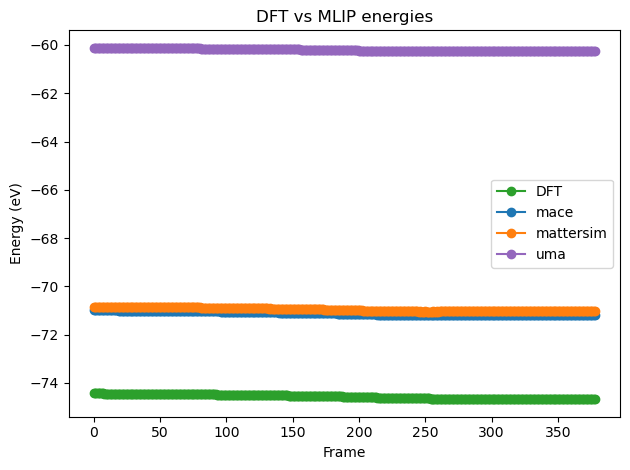

Saved: /Users/elianorengel/Desktop/2026 Summer Research Program/Mlip-dft-comparison-main/benchmark_outputs/plots/CO3_Rec_Ag111_2x2_all_models_energy.png


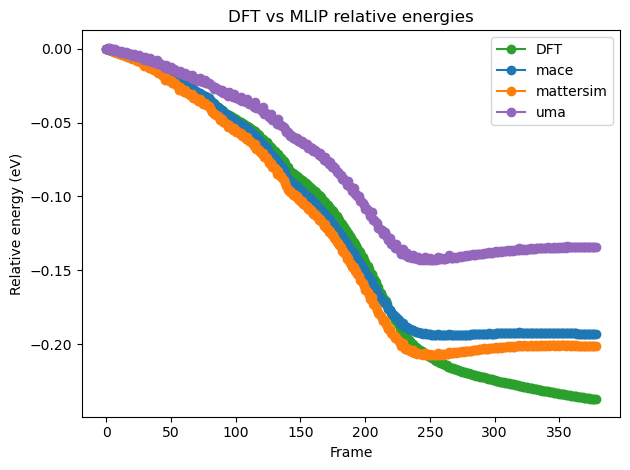

Saved: /Users/elianorengel/Desktop/2026 Summer Research Program/Mlip-dft-comparison-main/benchmark_outputs/plots/CO3_Rec_Ag111_2x2_all_models_relative_energy.png


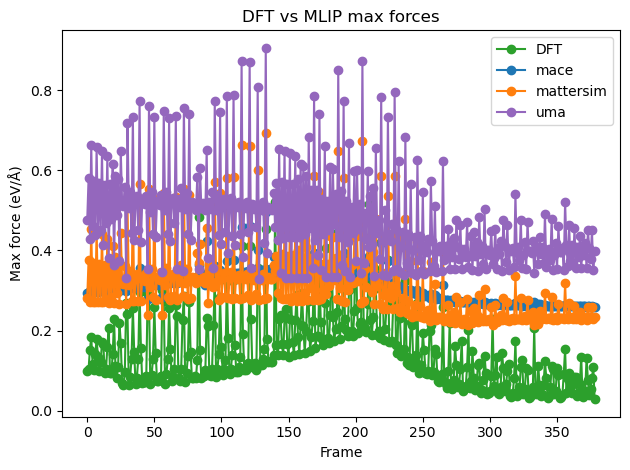

Saved: /Users/elianorengel/Desktop/2026 Summer Research Program/Mlip-dft-comparison-main/benchmark_outputs/plots/CO3_Rec_Ag111_2x2_all_models_max_force.png


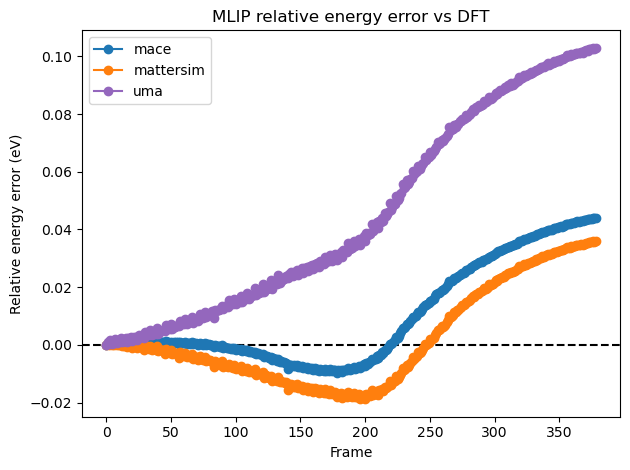

Saved: /Users/elianorengel/Desktop/2026 Summer Research Program/Mlip-dft-comparison-main/benchmark_outputs/plots/CO3_Rec_Ag111_2x2_all_models_relative_energy_error.png


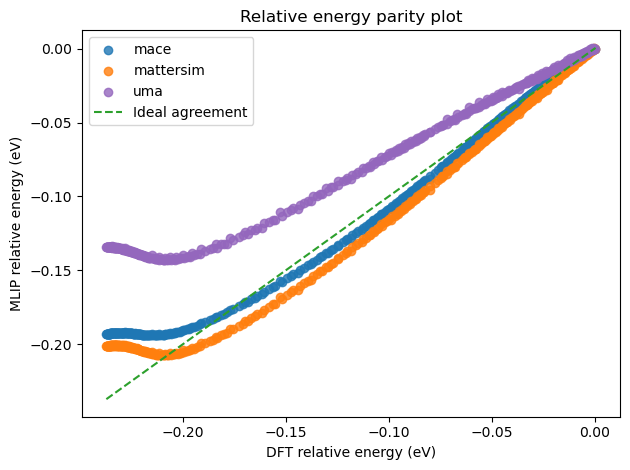

Saved: /Users/elianorengel/Desktop/2026 Summer Research Program/Mlip-dft-comparison-main/benchmark_outputs/plots/CO3_Rec_Ag111_2x2_all_models_relative_energy_parity.png


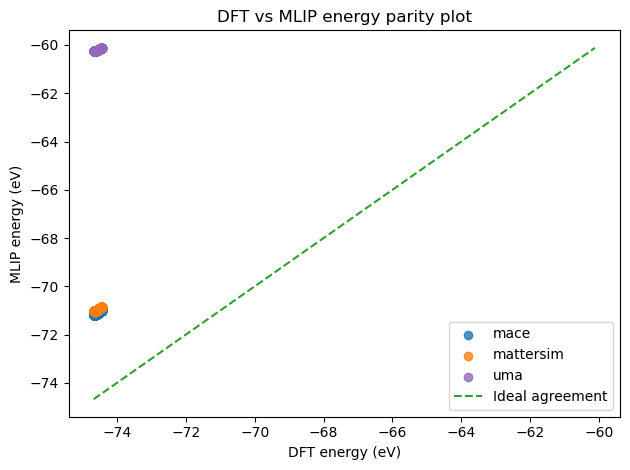

Saved: /Users/elianorengel/Desktop/2026 Summer Research Program/Mlip-dft-comparison-main/benchmark_outputs/plots/CO3_Rec_Ag111_2x2_all_models_energy_parity.png


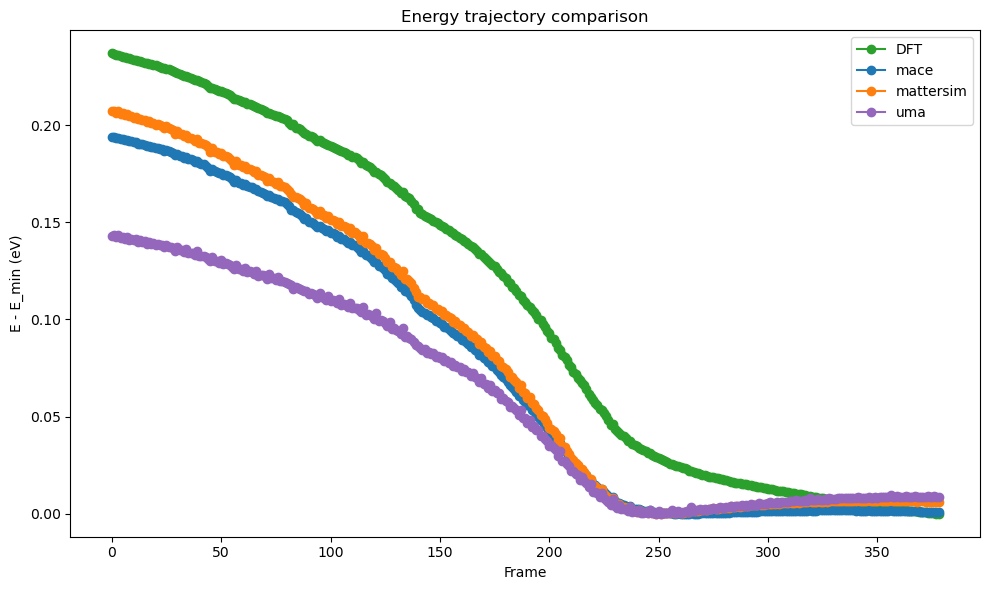

Saved: /Users/elianorengel/Desktop/2026 Summer Research Program/Mlip-dft-comparison-main/benchmark_outputs/plots/CO3_Rec_Ag111_2x2_all_models_energy_trajectory.png


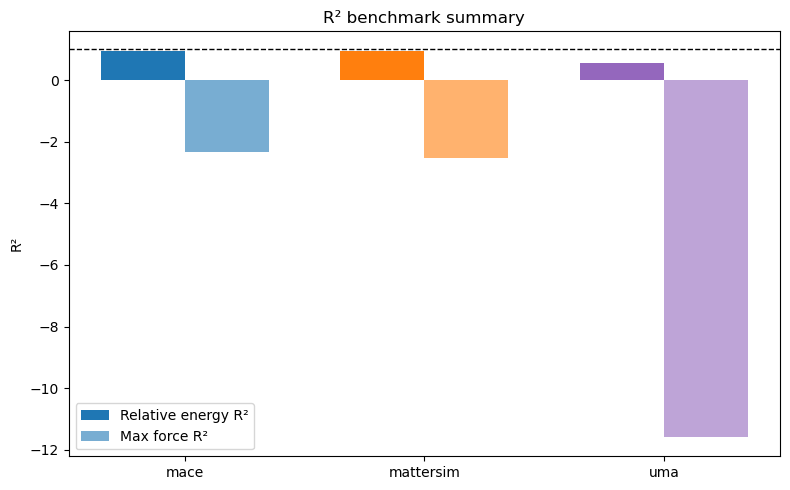

Saved: /Users/elianorengel/Desktop/2026 Summer Research Program/Mlip-dft-comparison-main/benchmark_outputs/plots/CO3_Rec_Ag111_2x2_r2_summary.png


In [ ]:
import matplotlib.pyplot as plt

PLOTS_FOLDER = OUTPUT_FOLDER / "plots"
PLOTS_FOLDER.mkdir(parents=True, exist_ok=True)

print(f"Plots will be saved in: {PLOTS_FOLDER}")

MODEL_COLORS = {
    "dft": "tab:green",
    "mace": "tab:blue",
    "mattersim": "tab:orange",
    "uma": "tab:purple",
}

def get_model_color(model):
    return MODEL_COLORS.get(model.lower(), None)



def save_all_models_relative_energy_parity_plot(comparison, output_folder, run_label):
    """
    Plot DFT relative energy vs MLIP relative energy for all available models.

    This removes the absolute energy offset between methods and checks whether
    each MLIP follows the same relative energy landscape as DFT.
    """
    if comparison.empty:
        print("No comparison data available for relative energy parity plot.")
        return

    plt.figure()

    all_x = []
    all_y = []

    for model, group in comparison.groupby("model"):
        group = group.sort_values("frame")

        x = group["dft_relative_energy_eV"]
        y = group["mlip_relative_energy_eV"]

        valid = x.notna() & y.notna()

        if valid.sum() == 0:
            print(f"[{model}] Skipped relative energy parity plot because values are NaN.")
            continue

        plt.scatter(
            x[valid],
            y[valid],
            label=model,
            color=get_model_color(model),
            alpha=0.8
        )

        all_x.extend(x[valid].to_list())
        all_y.extend(y[valid].to_list())

    if not all_x or not all_y:
        print("No valid data found for relative energy parity plot.")
        return

    min_val = min(min(all_x), min(all_y))
    max_val = max(max(all_x), max(all_y))

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--",
        color=MODEL_COLORS["dft"],
        label="Ideal agreement"
    )

    plt.xlabel("DFT relative energy (eV)")
    plt.ylabel("MLIP relative energy (eV)")
    plt.title("Relative energy parity plot")
    plt.legend()
    plt.tight_layout()

    path = output_folder / f"{run_label}_all_models_relative_energy_parity.png"
    plt.savefig(path, dpi=300)
    plt.show()

    print(f"Saved: {path}")

def save_all_models_energy_plot(comparison, output_folder, run_label):
    """
    Plot DFT and all available MLIP energies in the same figure.
    """
    if comparison.empty:
        print("No comparison data available for combined energy plot.")
        return

    plt.figure()

    dft = comparison.drop_duplicates("frame").sort_values("frame")

    plt.plot(
        dft["frame"],
        dft["dft_energy_eV"],
        marker="o",
        label="DFT",
        color=MODEL_COLORS["dft"]
    )

    for model, group in comparison.groupby("model"):
        group = group.sort_values("frame")

        plt.plot(
            group["frame"],
            group["mlip_energy_eV"],
            marker="o",
            label=model,
            color=get_model_color(model)
        )

    plt.xlabel("Frame")
    plt.ylabel("Energy (eV)")
    plt.title("DFT vs MLIP energies")
    plt.legend()
    plt.tight_layout()

    path = output_folder / f"{run_label}_all_models_energy.png"
    plt.savefig(path, dpi=300)
    plt.show()

    print(f"Saved: {path}")


def save_all_models_energy_plot(comparison, output_folder, run_label):
    """
    Plot DFT and all available MLIP energies in the same figure.
    """
    if comparison.empty:
        print("No comparison data available for combined energy plot.")
        return

    plt.figure()

    dft = comparison.drop_duplicates("frame").sort_values("frame")

    plt.plot(
        dft["frame"],
        dft["dft_energy_eV"],
        marker="o",
        label="DFT",
        color=MODEL_COLORS["dft"]
    )

    for model, group in comparison.groupby("model"):
        group = group.sort_values("frame")

        plt.plot(
            group["frame"],
            group["mlip_energy_eV"],
            marker="o",
            label=model,
            color=get_model_color(model)
        )

    plt.xlabel("Frame")
    plt.ylabel("Energy (eV)")
    plt.title("DFT vs MLIP energies")
    plt.legend()
    plt.tight_layout()

    path = output_folder / f"{run_label}_all_models_energy.png"
    plt.savefig(path, dpi=300)
    plt.show()

    print(f"Saved: {path}")

def save_all_models_relative_energy_plot(comparison, output_folder, run_label):
    """
    Plot DFT and all available MLIP relative energies in the same figure.

    Relative energies remove absolute offsets and make trends easier to compare.
    """
    if comparison.empty:
        print("No comparison data available for combined relative energy plot.")
        return

    plt.figure()

    dft = comparison.drop_duplicates("frame").sort_values("frame")

    plt.plot(
        dft["frame"],
        dft["dft_relative_energy_eV"],
        marker="o",
        label="DFT",
        color=MODEL_COLORS["dft"]
    )

    for model, group in comparison.groupby("model"):
        group = group.sort_values("frame")

        plt.plot(
            group["frame"],
            group["mlip_relative_energy_eV"],
            marker="o",
            label=model,
            color=get_model_color(model)
        )

    plt.xlabel("Frame")
    plt.ylabel("Relative energy (eV)")
    plt.title("DFT vs MLIP relative energies")
    plt.legend()
    plt.tight_layout()

    path = output_folder / f"{run_label}_all_models_relative_energy.png"
    plt.savefig(path, dpi=300)
    plt.show()

    print(f"Saved: {path}")

def save_all_models_force_plot(comparison, output_folder, run_label):
    """
    Plot DFT and all available MLIP maximum forces in the same figure.
    """
    required_columns = {
        "dft_max_force_eV_per_A",
        "mlip_max_force_eV_per_A"
    }

    if comparison.empty or not required_columns.issubset(comparison.columns):
        print("No force data available for combined force plot.")
        return

    plt.figure()

    dft = comparison.drop_duplicates("frame").sort_values("frame")

    plt.plot(
        dft["frame"],
        dft["dft_max_force_eV_per_A"],
        marker="o",
        label="DFT",
        color=MODEL_COLORS["dft"]
    )

    for model, group in comparison.groupby("model"):
        group = group.sort_values("frame")

        plt.plot(
            group["frame"],
            group["mlip_max_force_eV_per_A"],
            marker="o",
            label=model,
            color=get_model_color(model)
        )

    plt.xlabel("Frame")
    plt.ylabel("Max force (eV/Å)")
    plt.title("DFT vs MLIP max forces")
    plt.legend()
    plt.tight_layout()

    path = output_folder / f"{run_label}_all_models_max_force.png"
    plt.savefig(path, dpi=300)
    plt.show()

    print(f"Saved: {path}")

def save_all_models_relative_energy_error_plot(comparison, output_folder, run_label):
    """
    Plot relative energy error for all available MLIPs.
    """
    if comparison.empty:
        print("No comparison data available for combined relative energy error plot.")
        return

    plt.figure()
    plt.axhline(0, linestyle="--", color="black")

    for model, group in comparison.groupby("model"):
        group = group.sort_values("frame")

        plt.plot(
            group["frame"],
            group["relative_energy_error_eV"],
            marker="o",
            label=model,
            color=get_model_color(model)
        )

    plt.xlabel("Frame")
    plt.ylabel("Relative energy error (eV)")
    plt.title("MLIP relative energy error vs DFT")
    plt.legend()
    plt.tight_layout()

    path = output_folder / f"{run_label}_all_models_relative_energy_error.png"
    plt.savefig(path, dpi=300)
    plt.show()

    print(f"Saved: {path}")

def save_all_models_energy_parity_plot(comparison, output_folder, run_label):
    """
    Plot DFT absolute energy vs MLIP absolute energy for all available models.

    This shows absolute energy offsets between DFT and each MLIP.
    For trend comparison, the relative energy parity plot is usually more useful.
    """
    if comparison.empty:
        print("No comparison data available for energy parity plot.")
        return

    plt.figure()

    all_x = []
    all_y = []

    for model, group in comparison.groupby("model"):
        group = group.sort_values("frame")

        x = group["dft_energy_eV"]
        y = group["mlip_energy_eV"]

        valid = x.notna() & y.notna()

        if valid.sum() == 0:
            print(f"[{model}] Skipped energy parity plot because values are NaN.")
            continue

        plt.scatter(
            x[valid],
            y[valid],
            label=model,
            color=get_model_color(model),
            alpha=0.8
        )

        all_x.extend(x[valid].to_list())
        all_y.extend(y[valid].to_list())

    if not all_x or not all_y:
        print("No valid data found for energy parity plot.")
        return

    min_val = min(min(all_x), min(all_y))
    max_val = max(max(all_x), max(all_y))

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--",
        color=MODEL_COLORS["dft"],
        label="Ideal agreement"
    )

    plt.xlabel("DFT energy (eV)")
    plt.ylabel("MLIP energy (eV)")
    plt.title("DFT vs MLIP energy parity plot")
    plt.legend()
    plt.tight_layout()

    path = output_folder / f"{run_label}_all_models_energy_parity.png"
    plt.savefig(path, dpi=300)
    plt.show()

    print(f"Saved: {path}")

def save_all_models_energy_trajectory_plot(comparison, output_folder, run_label):
    """
    Plot E - E_min along the trajectory for DFT and all available MLIPs.

    This is useful for comparing whether each MLIP follows the same
    relaxation trajectory shape as DFT, independently of absolute energy offsets.
    """
    if comparison.empty:
        print("No comparison data available for energy trajectory plot.")
        return

    plt.figure(figsize=(10, 6))

    # DFT appears once per model in the comparison table, so keep one row per frame.
    dft = comparison.drop_duplicates("frame").sort_values("frame")

    dft_traj = dft["dft_energy_eV"] - dft["dft_energy_eV"].min()

    plt.plot(
        dft["frame"],
        dft_traj,
        marker="o",
        label="DFT",
        color=MODEL_COLORS["dft"]
    )

    for model, group in comparison.groupby("model"):
        group = group.sort_values("frame")

        mlip_traj = group["mlip_energy_eV"] - group["mlip_energy_eV"].min()

        plt.plot(
            group["frame"],
            mlip_traj,
            marker="o",
            label=model,
            color=get_model_color(model)
        )

    plt.xlabel("Frame")
    plt.ylabel("E - E_min (eV)")
    plt.title("Energy trajectory comparison")
    plt.legend()
    plt.tight_layout()

    path = output_folder / f"{run_label}_all_models_energy_trajectory.png"
    plt.savefig(path, dpi=300)
    plt.show()

    print(f"Saved: {path}")

def save_r2_summary_bar_plot(error_summary, output_folder, run_label):
    """
    Plot R² values for relative energies and forces.

    R² close to 1 means the MLIP follows the DFT trend well.
    """
    if error_summary.empty:
        print("No error summary available for R² plot.")
        return

    plt.figure(figsize=(8, 5))

    x = np.arange(len(error_summary["model"]))
    width = 0.35

    colors = [
        get_model_color(model)
        for model in error_summary["model"]
    ]

    plt.bar(
        x - width / 2,
        error_summary["r2_relative_energy"],
        width,
        label="Relative energy R²",
        color=colors
    )

    if "r2_max_force" in error_summary.columns:
        plt.bar(
            x + width / 2,
            error_summary["r2_max_force"],
            width,
            label="Max force R²",
            alpha=0.6,
            color=colors
        )

    plt.axhline(1, linestyle="--", color="black", linewidth=1)

    plt.xticks(x, error_summary["model"])
    plt.ylabel("R²")
    plt.title("R² benchmark summary")
    plt.legend()
    plt.tight_layout()

    path = output_folder / f"{run_label}_r2_summary.png"
    plt.savefig(path, dpi=300)
    plt.show()

    print(f"Saved: {path}")

save_all_models_energy_plot(comparison, PLOTS_FOLDER, CONFIG["run_label"])
save_all_models_energy_parity_plot(comparison, PLOTS_FOLDER, CONFIG["run_label"])
save_all_models_relative_energy_plot(comparison, PLOTS_FOLDER, CONFIG["run_label"])
save_all_models_relative_energy_error_plot(comparison, PLOTS_FOLDER, CONFIG["run_label"])

save_all_models_relative_energy_parity_plot(comparison, PLOTS_FOLDER, CONFIG["run_label"])
save_all_models_force_plot(comparison, PLOTS_FOLDER, CONFIG["run_label"])
save_all_models_energy_trajectory_plot(comparison, PLOTS_FOLDER, CONFIG["run_label"])
save_r2_summary_bar_plot(error_summary, PLOTS_FOLDER, CONFIG["run_label"])


In [18]:
print("Benchmark completed successfully")
print("-" * 32)

print(f"Dataset: {CONFIG['run_label']}")
print(f"DFT frames analyzed: {len(dft_frames)}")
print(f"Models evaluated: {list(model_outputs.keys())}")

print("\nGenerated files:")
print(f"  CSV summaries: {OUTPUT_FOLDER}")
print(f"  Plots: {PLOTS_FOLDER}")


Benchmark completed successfully
--------------------------------
Dataset: CO3_Rec_Ag111_2x2
DFT frames analyzed: 379
Models evaluated: ['mace', 'mattersim', 'uma']

Generated files:
  CSV summaries: /Users/elianorengel/Desktop/2026 Summer Research Program/Mlip-dft-comparison-main/benchmark_outputs
  Plots: /Users/elianorengel/Desktop/2026 Summer Research Program/Mlip-dft-comparison-main/benchmark_outputs/plots


## 12. Notes for future extensions

Possible next steps:

1. Add clean slab and gas-phase references for adsorption energy calculations.
2. Add MLIP-driven geometry relaxation as a separate benchmark mode.
3. Add support for reading ASE `.db` files if the database contains stored structures.

The default benchmark should remain the fixed-DFT-geometry comparison because it provides the cleanest direct comparison between DFT and MLIP predictions.
